## Import Modules

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import time

from torchaudio.functional import add_noise

In [2]:
BATCH_SIZE = 2048
EPOCHS = 1000
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
GRADIENT_CLIPPING = False
CLIP_VALUE = 100
STD_DEV_MEASURE_MOD = 50
STD_DEV_MEASURE_SCALE = 1
LOSS_REDUCTION = "mean"    # sum or mean
TRAIN_RATIO = 0.8
BETA_CYCLES=10

## Definitions

In [3]:
from data_processing import PatchProcessor
import data_processing

params = data_processing.get_params()
processor = PatchProcessor(params)

df = pd.read_csv("E:\\Coding\\vae-main\\dx7\\dx7.patchparams")

df = processor.normalize(df)
df_encoded, expanded_types = processor.one_hot_dataframe(df)

mse_mask, be_mask, ce_mask, alg_mask = processor.make_masks(expanded_types)
masks = (mse_mask, be_mask, ce_mask, alg_mask)
algorithms, alibi_distances = data_processing.get_algorithms()

encoded_data_array = df_encoded.to_numpy()
x_data = torch.tensor(encoded_data_array, dtype=torch.float32)
dataset = torch.utils.data.TensorDataset(x_data)

In [4]:
from helpers import *

BETA = 0.01
mse_loss = nn.MSELoss()

def latent_display(model, name):
    train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    visualize_latent_space(model, dataloader=train_dataloader, device="cuda", NAME=name)

def model_size(model):
    model_parameters = filter(lambda p: p.requires_grad, model.parameters())
    params = sum([np.prod(p.size()) for p in model_parameters])
    return params

def warmup(epoch, max_epoch, rate, max_beta):
    y = min(rate * epoch, rate * max_epoch)
    y = min(y, max_beta)
    return y

def cyclic_beta_schedule(epoch, max_beta, period=100):
    # see: https://www.microsoft.com/en-us/research/blog/less-pain-more-gain-a-simple-method-for-vae-training-with-less-of-that-kl-vanishing-agony/
    half_period = period // 2
    i = epoch % period
     # hold at max for last half of period
    if i > half_period: return max_beta
     # grow to max for first half of period
    return i / half_period * max_beta

def train_model(vae, masks, train_dataloader, val_dataloader, device, debug=False, chain=False, mse_coeff=1, alg_coeff=1):
    mse_mask, be_mask, ce_mask, alg_mask = masks

    # register hook for gradient clipping
    if GRADIENT_CLIPPING:
        for param in vae.parameters():
            param.register_hook(lambda grad: torch.clamp(grad, -CLIP_VALUE, CLIP_VALUE))

    # use AdamW instead as Adam is broken
    optimizer = torch.optim.AdamW(vae.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LEARNING_RATE,
        pct_start=0.0,
        steps_per_epoch=len(train_dataloader),
        epochs=EPOCHS
    )

    train_losses, train_mse_recon_losses, train_ce_recon_losses, train_kl_losses, train_be_recon_losses, train_algo_recon_losses  = [], [], [], [], [], []
    val_losses, val_mse_recon_losses, val_ce_recon_losses, val_kl_losses, val_be_recon_losses, val_algo_recon_losses = [], [], [], [], [], []

    alg_offset_start = 100
    alg_warmup = 100

    for epoch in range(EPOCHS):
        start_time = time.time()
        train_epoch_total_loss = 0
        train_epoch_mse_recon_loss = 0
        train_epoch_ce_recon_loss = 0
        train_epoch_be_recon_loss = 0
        train_epoch_kl_loss = 0
        train_sparsity_loss = 0
        train_epoch_algo_loss = 0
        train_total_mse_loss = 0

        val_epoch_total_loss = 0
        val_epoch_mse_recon_loss = 0
        val_epoch_ce_recon_loss = 0
        val_epoch_be_recon_loss = 0
        val_epoch_kl_loss = 0
        val_epoch_sparsity_loss = 0
        val_epoch_algo_loss = 0
        val_total_mse_loss = 0
        if epoch % STD_DEV_MEASURE_MOD == 0:
            plt.clf()

        beta = cyclic_beta_schedule(epoch, BETA, period=(EPOCHS // BETA_CYCLES))
        vae.train()
        batch_progress = 0
        for batch in train_dataloader:
            batch_progress += 1

            x_batch = batch[0].to(device)
            if epoch < alg_offset_start:
                alg_coeff_sched = 0.001
            elif epoch > alg_warmup:
                alg_coeff_sched = 1
            else:
                alg_coeff_sched = torch.sigmoid(torch.tensor(batch_progress / len(train_dataloader) / alg_warmup + (epoch - alg_offset_start) / alg_warmup))

            recon_x, mu, logvar, sparse_loss = vae(x_batch, beta=beta)

            drift = torch.tensor(0.0).to(device)
            if chain:
                vae.reparameterization = False
                double_reconstruction, _, _, _ = vae(recon_x)
                triple_reconstruction, _, _, _ = vae(double_reconstruction)
                vae.reparameterization = True

                drift += mse_loss(recon_x, double_reconstruction)
                drift += mse_loss(double_reconstruction, triple_reconstruction)

            train_total_loss, train_mse_recon_loss, train_ce_recon_loss, train_be_recon_loss, train_kl_loss, total_mse, alg_loss = vae_total_loss(
                recon_x,
                x_batch,
                be_mask,
                ce_mask,
                mse_mask,
                alg_mask,
                mu,
                logvar,
                beta,
                use_kl=True,
                mse_coeff=1,
                alg_coeff=alg_coeff_sched
            )

            #train_total_loss += drift

            optimizer.zero_grad()
            train_total_loss.backward()
            optimizer.step()
            scheduler.step()

            train_epoch_total_loss += train_total_loss.item()
            train_epoch_mse_recon_loss += train_mse_recon_loss.item()
            train_epoch_ce_recon_loss += train_ce_recon_loss.item()
            train_epoch_be_recon_loss += train_be_recon_loss.item()
            train_epoch_kl_loss += train_kl_loss.item()
            train_epoch_algo_loss += alg_loss.item()
            train_sparsity_loss += drift.item()
            train_total_mse_loss += total_mse.item()

        vae.eval() # <- mode for just evaluating
        with torch.no_grad(): # <- don't track gradients
            for batch in val_dataloader:
                x_batch = batch[0].to(device)
                recon_x, mu, logvar, sparse_loss = vae(x_batch)

                drift = torch.tensor(0.0).to(device)
                if chain:
                    vae.reparameterization = False
                    double_reconstruction, _, _, _ = vae(recon_x)
                    triple_reconstruction, _, _, _ = vae(double_reconstruction)
                    vae.reparameterization = True

                    drift += mse_loss(recon_x, double_reconstruction)
                    drift += mse_loss(double_reconstruction, triple_reconstruction)

                val_total_loss, val_mse_recon_loss, val_ce_recon_loss, val_be_recon_loss, val_kl_loss, val_mse_total, alg_loss = vae_total_loss(
                    recon_x,
                    x_batch,
                    be_mask,
                    ce_mask,
                    mse_mask,
                    alg_mask,
                    mu,
                    logvar,
                    beta,
                )

                val_total_loss += drift

                val_epoch_total_loss += val_total_loss.item()
                val_epoch_mse_recon_loss += val_mse_recon_loss.item()
                val_epoch_ce_recon_loss += val_ce_recon_loss.item()
                val_epoch_be_recon_loss += val_be_recon_loss.item()
                val_epoch_kl_loss += val_kl_loss.item()
                val_total_mse_loss += val_mse_total.item()
                val_epoch_algo_loss += alg_loss.item()
                val_epoch_sparsity_loss += drift.item()

        train_avg_total_loss = train_epoch_total_loss           / len(train_dataloader)
        train_avg_mse_recon_loss = train_epoch_mse_recon_loss   / len(train_dataloader)
        train_avg_ce_recon_loss = train_epoch_ce_recon_loss     / len(train_dataloader)
        train_avg_be_recon_loss = train_epoch_be_recon_loss     / len(train_dataloader)
        train_avg_kl_loss = train_epoch_kl_loss                 / len(train_dataloader)
        train_avg_algo_loss = train_epoch_algo_loss             / len(train_dataloader)
        train_avg_sparsity_loss = train_sparsity_loss           / len(train_dataloader)
        train_avg_epoch_mse_loss = train_total_mse_loss         / len(train_dataloader)

        train_losses.append(train_avg_total_loss)
        train_mse_recon_losses.append(train_avg_mse_recon_loss)
        train_ce_recon_losses.append(train_avg_ce_recon_loss)
        train_be_recon_losses.append(train_avg_be_recon_loss)
        train_algo_recon_losses.append(train_avg_algo_loss)

        train_kl_losses.append(train_avg_kl_loss)

        val_avg_total_loss = val_epoch_total_loss               / len(val_dataloader)
        val_avg_mse_recon_loss = val_epoch_mse_recon_loss       / len(val_dataloader)
        val_avg_ce_recon_loss = val_epoch_ce_recon_loss         / len(val_dataloader)
        val_avg_be_recon_loss = val_epoch_be_recon_loss         / len(val_dataloader)
        val_avg_kl_loss = val_epoch_kl_loss                     / len(val_dataloader)
        val_avg_algo_loss = val_epoch_algo_loss                 / len(val_dataloader)
        val_avg_sparsity_loss = val_epoch_sparsity_loss         / len(val_dataloader)
        val_avg_epoch_mse_loss = val_total_mse_loss             / len(val_dataloader)

        val_losses.append(val_avg_total_loss)
        val_mse_recon_losses.append(val_avg_mse_recon_loss)
        val_ce_recon_losses.append(val_avg_ce_recon_loss)
        val_be_recon_losses.append(val_avg_be_recon_loss)
        val_algo_recon_losses.append(val_avg_algo_loss)
        val_kl_losses.append(val_avg_kl_loss)

        end_time = time.time()
        runtime = end_time - start_time

        if debug:
            print("-" * 50)
            print(f"Epoch {epoch+1}/{EPOCHS} done in {runtime:.4f} seconds")
            print(f"Beta: {beta:.4f}")
            print(f"Learning Rate: {scheduler.get_last_lr()[0]:.8f}")

            print(f"Training Loss: {train_avg_total_loss:.4f}")
            print(f"\tTraining MSE Reconstruction Loss: {train_avg_mse_recon_loss:.4f}")
            print(f"\tTraining CE Reconstruction Loss: {train_avg_ce_recon_loss:.4f}")
            print(f"\tTraining BE Reconstruction Loss: {train_avg_be_recon_loss:.4f}")
            print(f"\tTraining Algorithm Loss: {train_avg_algo_loss:.4f}")
            print(f"\tTraining KL Loss: {train_avg_kl_loss:.4f}")
            print(f"\tTraining Sparsity Loss: {train_avg_sparsity_loss:.4f}")
            print(f"\tTraining Total Drift: {train_avg_epoch_mse_loss:.4f}")

            print(f"Validation Loss: {val_avg_total_loss:.4f}")
            print(f"\tValidation MSE Reconstruction Loss: {val_avg_mse_recon_loss:.4f}")
            print(f"\tValidation CE Reconstruction Loss: {val_avg_ce_recon_loss:.4f}")
            print(f"\tValidation BE Reconstruction Loss: {val_avg_be_recon_loss:.4f}")
            print(f"\tValidation Algorithm Loss: {val_avg_algo_loss:.4f}")
            print(f"\tValidation KL Loss: {val_avg_kl_loss:.4f}")
            print(f"\tValidation Sparsity Loss: {val_avg_sparsity_loss:.4f}")
            print(f"\tValidation Total Drift: {val_avg_epoch_mse_loss:.4f}")

            print("-" * 50)

    return vae, train_losses, train_mse_recon_losses, train_ce_recon_losses, train_kl_losses, train_be_recon_losses, train_algo_recon_losses, val_losses, val_mse_recon_losses, val_ce_recon_losses, val_be_recon_losses, val_kl_losses, val_algo_recon_losses

def train_loop(model, chain=False, mse_coeff=1.0):
    # determine device
    has_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if has_cuda else "cpu")
    if has_cuda:
        print("Using GPU")
    else:
        print("Using CPU")

    train_data_count = round(len(dataset) * TRAIN_RATIO)
    val_data_count = len(dataset) - train_data_count

    print("Total samples:", len(dataset))
    print("Training samples:", train_data_count)
    print("Validation samples:", val_data_count)

    train_data, val_data = torch.utils.data.random_split(dataset, [train_data_count, val_data_count])
    train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)

    model.to(device=device)

    print(f"{model_size(model)} Parameters")

    # train vae
    print("Training VAE...")
    vae, train_losses, train_mse_recon_losses, train_ce_recon_losses, train_kl_losses, train_be_recon_losses, train_algo_recon_losses, val_losses, val_mse_recon_losses, val_ce_recon_losses, val_be_recon_losses, val_kl_losses, val_algo_recon_loss = train_model(model, masks, train_dataloader, val_dataloader, device, debug=True, chain=chain, mse_coeff=mse_coeff)
    print("VAE complete.")

    # visualize results
    print("Plotting loss and UMAP of latent space...")
    os.makedirs("./models/" + NAME, exist_ok=True)
    plot_loss(train_losses, train_mse_recon_losses, train_ce_recon_losses, train_kl_losses, train_be_recon_losses, train_algo_recon_losses, val_losses, val_mse_recon_losses, val_ce_recon_losses, val_be_recon_losses, val_algo_recon_loss, val_kl_losses, NAME)

    train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    visualize_latent_space(model, dataloader=train_dataloader, device="cuda", NAME=NAME)

    # save the vae parameters
    torch.save(vae.state_dict(), "./models/" + NAME + "/model.pth")
    torch.save(vae, "./models/" + NAME + "/model.model")

    summary_name = "./models/" + NAME + "/summary.txt"

    with open(summary_name, 'w') as f:
        f.write(f"Train Total Loss: {train_losses[-1]}\n")
        f.write(f"Train MSE Loss: {train_mse_recon_losses[-1]}\n")
        f.write(f"Train CE Loss: {train_ce_recon_losses[-1]}\n")
        f.write(f"Train BE Loss: {train_be_recon_losses[-1]}\n")
        f.write(f"Train Algorithm CE Loss: {train_algo_recon_losses[-1]}\n")

        f.write(f"Validation Total Loss: {train_losses[-1]}\n")
        f.write(f"Validation MSE Loss: {train_mse_recon_losses[-1]}\n")
        f.write(f"Validation CE Loss: {train_ce_recon_losses[-1]}\n")
        f.write(f"Validation BE Loss: {train_be_recon_losses[-1]}\n")
        f.write(f"Validation Algorithm CE Loss: {train_algo_recon_losses[-1]}\n")

In [5]:

from torchmetrics.classification import BinaryAUROC, BinaryAveragePrecision, MulticlassF1Score, MulticlassAccuracy, MulticlassAUROC, MulticlassPrecisionRecallCurve, BinaryPrecisionRecallCurve
import torch

c_lengths = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6]

import torch
import torch.nn.functional as F
from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassAUROC,
    MulticlassAveragePrecision
)

def update_grouped_categorical_metrics(
    pred,
    target,
    ce_mask,
    c_lengths,
    categorical_metrics
):

    logits_all = pred[:, ce_mask]       # [B, sum(c_lengths)]
    targets_all = target[:, ce_mask]    # [B, sum(c_lengths)]

    start = 0

    for group_idx, length in enumerate(c_lengths):
        end = start + length

        logits_group = logits_all[:, start:end]     # [B, C]
        targets_group = targets_all[:, start:end]   # [B, C]

        # one-hot → class index
        target_indices = targets_group.argmax(dim=1)

        # softmax probabilities
        probs = F.softmax(logits_group, dim=1)

        # unpack metrics for this group
        (
            precision_metric,
            recall_metric,
            f1_metric,
            auroc_metric,
            prauc_metric
        ) = categorical_metrics[group_idx]

        if probs.shape[1] != length:
            pass

        # update metrics
        precision_metric.update(probs, target_indices)
        recall_metric.update(probs, target_indices)
        f1_metric.update(probs, target_indices)
        auroc_metric.update(probs, target_indices)
        prauc_metric.update(probs, target_indices)

        start = end

def compute_grouped_categorical_metrics(categorical_metrics):
    results = []

    for metrics in categorical_metrics:
        group_values = [m.compute() for m in metrics]
        results.append(torch.stack(group_values))

    return results
    # results = torch.stack(results)  # [num_groups, 5]
    # avg = results.mean(dim=0)
    #
    # return {
    #     "precision": avg[0],
    #     "recall": avg[1],
    #     "f1": avg[2],
    #     "auroc": avg[3],
    #     "prauc": avg[4]
    # }



def init_categorical_metrics(c_lengths, device=None):

    categorical_metrics = []

    for num_classes in c_lengths:
        precision = MulticlassPrecision(
            num_classes=num_classes,
            average="macro"
        )

        recall = MulticlassRecall(
            num_classes=num_classes,
            average="macro"
        )

        f1 = MulticlassF1Score(
            num_classes=num_classes,
            average="macro"
        )

        auroc = MulticlassAUROC(
            num_classes=num_classes
        )

        prauc = MulticlassAveragePrecision(
            num_classes=num_classes
        )

        if device is not None:
            precision = precision.to(device)
            recall = recall.to(device)
            f1 = f1.to(device)
            auroc = auroc.to(device)
            prauc = prauc.to(device)

        categorical_metrics.append(
            (precision, recall, f1, auroc, prauc)
        )

    return categorical_metrics


def evaluate(pred, target, binary_metrics, categorical_metrics, algorithm_metrics, masks):
    device = pred.device

    mse_mask, be_mask, ce_mask, alg_mask = masks

    be_mask = be_mask.to(device)
    ce_mask = ce_mask.to(device)
    mse_mask = mse_mask.to(device)
    alg_mask = alg_mask.to(device)

    if be_mask.any():
        # Slice masked logits and targets
        logits = pred[:, be_mask]        # [B, num_be_features]
        targets = target[:, be_mask]     # [B, num_be_features]

        # Convert logits → probabilities
        probs = torch.sigmoid(logits)    # [B, num_be_features]

        # Make sure targets are floats (0/1)
        targets = targets.float()        # [B, num_be_features]

        # Unpack metrics tuple
        auroc_metric, prauc_metric = binary_metrics

        # Update metrics
        auroc_metric.update(probs, targets)
        # Loop over BE features

        for i in range(probs.shape[1]):
            # shape [B]
            prob_i = probs[:, i]
            target_i = targets[:, i].long()  # must be int/long, shape [B]

            # Update per-feature PR curve
            prauc_metric.update(prob_i, target_i)

    update_grouped_categorical_metrics(pred, target, ce_mask, c_lengths, categorical_metrics)

    if alg_mask.any():
        logits = pred[:, alg_mask]
        targets = target[:, alg_mask].float()

        probs = torch.sigmoid(logits)

        targets = targets.argmax(dim=1)

        auroc_metric, prauc_metric = algorithm_metrics

        auroc_metric.update(probs, targets)
        prauc_metric.update(probs, targets)


def evaluate_model(vae, masks, train_dataloader):
    vae.eval() # <- mode for just evaluating

    with (torch.no_grad()): # <- don't track gradients
        be_auroc_metric = BinaryAUROC()
        be_prauc_metric = BinaryPrecisionRecallCurve()
        binary_metrics = (be_auroc_metric, be_prauc_metric)

        categorical_metrics = init_categorical_metrics(c_lengths)

        num_classes = 32
        alg_auroc = MulticlassAUROC(
                num_classes=num_classes
            )

        alg_prauc = MulticlassAveragePrecision(
            num_classes=num_classes
        )

        algorithm_metrics = (alg_auroc, alg_prauc)

        vae.train()

        device = "cuda"
        vae = vae.to(device)
        for batch in train_dataloader:
            x_batch = batch[0].to(device)

            recon_x, mu, logvar, sparse_loss = vae(x_batch)

            recon_x = recon_x.to("cpu")
            x_batch = x_batch.to("cpu")

            evaluate(
                recon_x,
                x_batch,
                binary_metrics,
                categorical_metrics,
                algorithm_metrics,
                masks
            )

        categorical_results = compute_grouped_categorical_metrics(categorical_metrics)

        be_auroc_metric, be_prauc_metric = binary_metrics
        binary_auroc_result = be_auroc_metric.compute()

        ce_auroc_metric, ce_prauc_metric = algorithm_metrics
        alg_auroc_result = ce_auroc_metric.compute()

        for index in range(len(categorical_results)):
            group = categorical_results[index]
            name = names_in_order[index]
            print("-" * 14 + " " + name + " " + "-" * 14)
            print(f"precision: {group[0]}")
            print(f"recall: {group[1]}")
            print(f"f1: {group[2]}")
            print(f"auroc: {group[3]}")
            print(f"prauc: {group[4]}\n")

        averages = torch.stack(categorical_results).mean(dim=0)

        print(f"Average Categorical Var Precision: {averages[0]}")
        print(f"Average Categorical Var recall: {averages[1]}")
        print(f"Average Categorical Var f1: {averages[2]}")
        print(f"Average Categorical Var auroc: {averages[3]}")
        print(f"Average Categorical Var prauc: {averages[4]}\n")

        print(f"Binary: AUROC-{binary_auroc_result:.04}\tPRROC-")
        print(f"Algorithm: AUROC-{alg_auroc_result:.04}\tPRROC-")


In [6]:
names = ["operator6rate1", "operator6rate2", "operator6rate3", "operator6rate4", "operator6level1", "operator6level2", "operator6level3", "operator6level4", "operator6keyboardlevelscalingbreakpoint", "operator6keyboardlevelscalingleftdepth", "operator6keyboardlevelscalingrightdepth", "operator6keyboardlevelscalingleftcurve", "operator6keyboardlevelscalingrightcurve", "operator6keyboardratescaling", "operator6amplitudemodulationsensitivity", "operator6keyvelocitysensitivity", "operator6operatoroutputlevel", "operator6oscillatormode", "operator6frequencycoarse", "operator6frequencyfine", "operator6frequencydetune", "operator5rate1", "operator5rate2", "operator5rate3", "operator5rate4", "operator5level1", "operator5level2", "operator5level3", "operator5level4", "operator5keyboardlevelscalingbreakpoint", "operator5keyboardlevelscalingleftdepth", "operator5keyboardlevelscalingrightdepth", "operator5keyboardlevelscalingleftcurve", "operator5keyboardlevelscalingrightcurve", "operator5keyboardratescaling", "operator5amplitudemodulationsensitivity", "operator5keyvelocitysensitivity", "operator5operatoroutputlevel", "operator5oscillatormode", "operator5frequencycoarse", "operator5frequencyfine", "operator5frequencydetune", "operator4rate1", "operator4rate2", "operator4rate3", "operator4rate4", "operator4level1", "operator4level2", "operator4level3", "operator4level4", "operator4keyboardlevelscalingbreakpoint", "operator4keyboardlevelscalingleftdepth", "operator4keyboardlevelscalingrightdepth", "operator4keyboardlevelscalingleftcurve", "operator4keyboardlevelscalingrightcurve", "operator4keyboardratescaling", "operator4amplitudemodulationsensitivity", "operator4keyvelocitysensitivity", "operator4operatoroutputlevel", "operator4oscillatormode", "operator4frequencycoarse", "operator4frequencyfine", "operator4frequencydetune", "operator3rate1", "operator3rate2", "operator3rate3", "operator3rate4", "operator3level1", "operator3level2", "operator3level3", "operator3level4", "operator3keyboardlevelscalingbreakpoint", "operator3keyboardlevelscalingleftdepth", "operator3keyboardlevelscalingrightdepth", "operator3keyboardlevelscalingleftcurve", "operator3keyboardlevelscalingrightcurve", "operator3keyboardratescaling", "operator3amplitudemodulationsensitivity", "operator3keyvelocitysensitivity", "operator3operatoroutputlevel", "operator3oscillatormode", "operator3frequencycoarse", "operator3frequencyfine", "operator3frequencydetune", "operator2rate1", "operator2rate2", "operator2rate3", "operator2rate4", "operator2level1", "operator2level2", "operator2level3", "operator2level4", "operator2keyboardlevelscalingbreakpoint", "operator2keyboardlevelscalingleftdepth", "operator2keyboardlevelscalingrightdepth", "operator2keyboardlevelscalingleftcurve", "operator2keyboardlevelscalingrightcurve", "operator2keyboardratescaling", "operator2amplitudemodulationsensitivity", "operator2keyvelocitysensitivity", "operator2operatoroutputlevel", "operator2oscillatormode", "operator2frequencycoarse", "operator2frequencyfine", "operator2frequencydetune", "operator1rate1", "operator1rate2", "operator1rate3", "operator1rate4", "operator1level1", "operator1level2", "operator1level3", "operator1level4", "operator1keyboardlevelscalingbreakpoint", "operator1keyboardlevelscalingleftdepth", "operator1keyboardlevelscalingrightdepth", "operator1keyboardlevelscalingleftcurve", "operator1keyboardlevelscalingrightcurve", "operator1keyboardratescaling", "operator1amplitudemodulationsensitivity", "operator1keyvelocitysensitivity", "operator1operatoroutputlevel", "operator1oscillatormode", "operator1frequencycoarse", "operator1frequencyfine", "operator1frequencydetune", "pitchegrate1", "pitchegrate2", "pitchegrate3", "pitchegrate4", "pitcheglevel1", "pitcheglevel2", "pitcheglevel3", "pitcheglevel4", "algorithm", "feedback", "oscillatorkeysync", "lfospeed", "lfodelay", "lfopitchmodulationdepth", "lfoamplitudemodulationdepth", "lfokeysync", "lfowave", "lfopitchmodulationsensitivity", "transpose"]
types = ["m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "c", "c", "m", "m", "m", "m", "b", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "c", "c", "m", "m", "m", "m", "b", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "c", "c", "m", "m", "m", "m", "b", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "c", "c", "m", "m", "m", "m", "b", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "c", "c", "m", "m", "m", "m", "b", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "c", "c", "m", "m", "m", "m", "b", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "m", "c", "m", "b", "m", "m", "m", "m", "b", "c", "m", "m"]

names_in_order = []

for index in range(len(types)):
    if types[index] == "c" and names[index] != "algorithm":
        names_in_order.append(names[index])

In [7]:
## Ideas
# Masking and Patchout as augmentation and normalization
# Model randomness adde dby resampling as a different patch and a scale
# Final output is final patch minus the patch that the randomness cooresponds to

In [8]:
# from GraphTransformerAlibiGlobalToken import GraphTransformerAutoencoderAlibi
#
# LATENT_DIM = 16
# BETA = 0.1
# mask_type = None
# NAME = f"GraphTransformer-Alibi-Global-Token-ALIBI-Modulation-Latent-{LATENT_DIM}-Beta-{BETA}-Batch-{BATCH_SIZE}"
# model = GraphTransformerAutoencoderAlibi(input_size=21, latent_space=LATENT_DIM, d_model=128, depth=6, heads=4, mlp_dim=256, num_algorithms=32, num_global_params=67, sparsity_weight=1, reparameterization=True, algorithm_distance_matricies=alibi_distances, hard_prediction=False, geom_dim=32)
# train_loop(model, chain=False)

## Train Models

In [9]:
# from GraphTransformerAlibiGlobalToken import GraphTransformerAutoencoderAlibi
# Betas = [0.01, 0.5, 1]
# ratios = [0.01, 0.05, 0.1, 0.25]
# mask_types = ["noise", "zero"]
#
# LATENT_DIM = 16
# BATCH_SIZE = 512
# MSE_COEFF = 1
# for BETA in Betas:
#     for ratio in ratios:
#         for mask_type in mask_types:
#                 NAME = f"GraphTransformer-Alibi-Global-Token-Latent-{LATENT_DIM}-Beta-{BETA}-Batch-{BATCH_SIZE}-mask-{mask_type}-ratio-{ratio}"
#                 model = GraphTransformerAutoencoderAlibi(input_size=21, latent_space=LATENT_DIM, d_model=128, depth=6, heads=4, mlp_dim=256, num_algorithms=32, num_global_params=67, sparsity_weight=1, reparameterization=True, algorithm_distance_matricies=alibi_distances, masking=mask_type, mask_ratio=ratio)
#                 train_loop(model, chain=False, mse_coeff=MSE_COEFF)

In [10]:
import pandas as pd
from data_processing import PatchProcessor
import data_processing

candidates = pd.read_csv("E:\\Coding\\vae-main\\generation\\dx7.candidates")
df = pd.read_csv("E:\\Coding\\vae-main\\dx7\\dx7.patchparams")

params = data_processing.get_params()
processor = PatchProcessor(params)

names = candidates["name"].tolist()
candidate_df = df.loc[(df["name"].isin(names))]
candidate_df = candidate_df.drop_duplicates(subset=["name"], keep="first")
candidate_df = candidate_df.drop(columns=candidate_df.columns[0])

candidate_df = processor.normalize(candidate_df)
df_encoded, expanded_types = processor.one_hot_dataframe(candidate_df)

mse_mask, be_mask, ce_mask, alg_mask = processor.make_masks(expanded_types)
masks = (mse_mask, be_mask, ce_mask, alg_mask)
algorithms, alibi_distances = data_processing.get_algorithms()

encoded_data_array = df_encoded.to_numpy()
x_data = torch.tensor(encoded_data_array, dtype=torch.float32)
dataset = torch.utils.data.TensorDataset(x_data)

In [11]:
def test_performance(model, latent_size):
    BATCH_SIZE = 25
    alpha_vector = torch.tensor([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]).unsqueeze(1).unsqueeze(1).expand(11, BATCH_SIZE, latent_size)

    candidate_tensor = torch.tensor(x_data).to("cuda")
    latent_tensors = model.encode(candidate_tensor)

    finals = []
    for index in range(len(latent_tensors)):
        item = torch.tensor(latent_tensors[index]).cpu()
        all_others = torch.tensor(latent_tensors).cpu()

        a_vector = item.unsqueeze(0).expand(11, BATCH_SIZE, -1)
        b_vectors = all_others.unsqueeze(0).expand(11, BATCH_SIZE, -1)

        interpolated_vector = (1 - alpha_vector) * a_vector
        interpolated_vector = interpolated_vector + alpha_vector * b_vectors
        finals.append(interpolated_vector)

    final_patches = []
    for final in finals:
        A, B, C = final.shape
        final = final.view(-1, LATENT_DIM).to("cuda")
        final_patch = model.generate(final)
        final = final_patch.view(A, B, -1)
        final = final.permute(1, 0, 2)
        final_patches.append(final)

    print(f"Algorithm Interpolation")

    start_index = 8
    for target_index in range(25):
        print(f"From {start_index} to {target_index}")
        for interp in range(11):
            orig_max = torch.argmax(candidate_tensor[start_index][176:176+32])
            target_max = torch.argmax(candidate_tensor[target_index][176:176+32])
            pred_max = torch.argmax(final_patches[start_index][target_index][interp][176:176+32])

            param_index = 0

            orig_param_1 = candidate_tensor[start_index][param_index]
            target_param_1 = candidate_tensor[target_index][param_index]
            pred_param_1 = final_patches[start_index][target_index][interp][param_index]

            print(f"\t\t\t{orig_max}  |  {pred_max}  |  {target_max}  |  {orig_param_1:.4f}  |  {pred_param_1:.4f}  |  {target_param_1:.4f}")

In [12]:
# model = torch.load("E:\\Coding\\vae-main\\vae\\models\\GraphTransformer-Alibi-Global-Token-ALIBI-Modulation-Latent-16-Beta-0.1-Batch-2048\\model.model", weights_only=False)
# LATENT_DIM = 16
# test_performance(model, 16)

In [13]:
from data_processing import PatchProcessorTensor
from datasets import tqdm

params = data_processing.get_params()
tensor_processor = PatchProcessorTensor(params)
mse_loss = nn.MSELoss(reduction='mean')

def train_model_spec(vae, train_dataloader, val_dataloader, device, debug=True):
    # use AdamW instead as Adam is broken
    optimizer = torch.optim.AdamW(vae.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    train_losses = []
    val_losses = []

    for epoch in range(EPOCHS):
        start_time = time.time()
        train_epoch_total_loss = 0
        val_epoch_total_loss = 0

        if epoch % STD_DEV_MEASURE_MOD == 0:
            plt.clf()

        vae.train()
        i = 0

        previous_25_losses = []

        train_epoch_total_loss_placeholder = 0
        for batch in tqdm(train_dataloader):
            spectrogram, notes, patch, midi_mask = batch

            patch = patch.squeeze(1)
            notes = notes.squeeze(1)

            spectrogram = spectrogram.to(device, dtype=torch.float)
            notes = notes.to(device)
            patch = patch.to(device)
            midi_mask = midi_mask.to((device))

            recon_spec = vae(patch, notes, midi_mask)

            total_loss = mse_loss(spectrogram[:,:,:256], recon_spec)
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            train_epoch_total_loss += total_loss.detach().item()

            i += 1

            previous_25_losses.append(total_loss.detach().item())

            if i % 25 == 0:
                print("-" * 10)
                print(f"Step: {i}")
                print(f"Training Loss: {train_epoch_total_loss / i:.4f}")
                train_losses.append(train_epoch_total_loss / i)

                print(f"Previous 25 Loss Average: {sum(previous_25_losses) / 25:.4f}")
                previous_25_losses.clear()


        torch.cuda.empty_cache()
        vae.eval()
        with torch.no_grad():
            for batch in val_dataloader:
                spectrogram, notes, patch, midi_mask = batch

                patch = patch.squeeze(1)
                notes = notes.squeeze(1)

                spectrogram = spectrogram.to(device, dtype=torch.float)

                notes = notes.to(device)
                patch = patch.to(device)
                midi_mask = midi_mask.to((device))

                recon_spec = vae(patch, notes, midi_mask)

                total_loss = mse_loss(spectrogram[:,:,:256], recon_spec)

                val_epoch_total_loss += total_loss.detach().item()

        torch.cuda.empty_cache()
        train_avg_total_loss = train_epoch_total_loss_placeholder / len(train_dataloader)
        train_losses.append(train_avg_total_loss)

        val_avg_total_loss = val_epoch_total_loss / len(val_dataloader)
        val_losses.append(val_avg_total_loss)

        end_time = time.time()
        runtime = end_time - start_time

        if debug:
            print("-" * 10)
            print(f"Epoch {epoch+1}/{EPOCHS} done in {runtime:.4f} seconds")
            print(f"Training Loss: {train_avg_total_loss:.4f}")
            print(f"Validation Loss: {val_avg_total_loss:.4f}")

        torch.save(vae.state_dict(), "./models/" + NAME + "/model.pth")
        torch.save(vae, "./models/" + NAME + "/model.model")

    return vae, train_losses, val_losses

def train_loop_spec(model, debug=True):
    # determine device
    has_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if has_cuda else "cpu")
    if has_cuda:
        print("Using GPU")
    else:
        print("Using CPU")

    train_data_count = round(len(dataset) * TRAIN_RATIO)
    val_data_count = len(dataset) - train_data_count

    print("Total samples:", len(dataset))
    print("Training samples:", train_data_count)
    print("Validation samples:", val_data_count)

    train_data, val_data = torch.utils.data.random_split(dataset, [train_data_count, val_data_count])
    train_dataloader = torch.utils.data.DataLoader(
        train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, persistent_workers=True,
    )

    val_dataloader = torch.utils.data.DataLoader(
        val_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4,
    )

    model.to(device=device)

    print(f"{model_size(model)} Parameters")

    # train vae
    print("Training VAE...")
    vae, train_losses, val_losses = train_model_spec(model, train_dataloader, val_dataloader, device, debug=debug)
    print("VAE complete.")

    # visualize results
    print("Plotting loss and UMAP of latent space...")
    os.makedirs("./models/" + NAME, exist_ok=True)

    plt.figure(figsize=(24, 6))
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["training", "validation"])
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    visualize_latent_space(model, dataloader=train_dataloader, device="cuda", NAME=NAME)

    # save the vae parameters
    torch.save(vae.state_dict(), "./models/" + NAME + "/model.pth")
    torch.save(vae, "./models/" + NAME + "/model.model")

    summary_name = "./models/" + NAME + "/summary.txt"

    with open(summary_name, 'w') as f:
        f.write(f"Train Total Loss: {train_losses[-1]}\n")
        f.write(f"Validation Total Loss: {train_losses[-1]}\n")

In [14]:
import torch

def copy_weights(old_model, new_model):
    layers_to_copy = [
        "input_projection",
        "encoder",
        "output_projection",
        "enc_global_film_gamma",
        "enc_global_film_beta",
        "alg_pred",
        "latent_to_geometry",
        "biases_to_token",
        "global_embedding",
        "global_pred",
        "learned_embeddings",
    ]

    old_state = old_model.state_dict()
    new_state = new_model.state_dict()

    for key in old_state:
        for layer in layers_to_copy:
            if key.startswith(layer):
                if key in new_state and old_state[key].shape == new_state[key].shape:
                    new_state[key] = old_state[key].clone()

    new_model.load_state_dict(new_state)

    return new_model


In [15]:
from GraphTransformerMidi import GraphTransformerMidi

LATENT_DIM = 16
model = GraphTransformerMidi(input_size=21, d_model=128, depth=6, heads=4, mlp_dim=256, num_algorithms=32, num_global_params=67, sparsity_weight=1, reparameterization=True, algorithm_distance_matricies=alibi_distances, hard_prediction=False)
old_model = torch.load("E:\\Coding\\vae-main\\vae\\models\\GraphTransformer-Alibi-Global-Token-ALIBI-Modulation-Latent-16-Beta-0.1-Batch-2048\\model.model", weights_only=False)

copy_weights(old_model, model)


GraphTransformerMidi(
  (input_projection): Linear(in_features=21, out_features=128, bias=True)
  (encoder): Transformer(
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (layers): ModuleList(
      (0-5): 6 x ModuleList(
        (0): Attention(
          (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attend): Softmax(dim=-1)
          (to_qkv): Linear(in_features=128, out_features=384, bias=False)
          (to_out): Linear(in_features=128, out_features=128, bias=False)
        )
        (1): FeedForward(
          (net): Sequential(
            (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=128, out_features=256, bias=True)
            (2): GELU(approximate='none')
            (3): Linear(in_features=256, out_features=128, bias=True)
          )
        )
        (2): MetricBiasUpdater(
          (geom_proj): Linear(in_features=128, out_features=7, bias=False)
        )
      )
    )
  )
  

In [1]:
from dataset import SpectrogramMidiStreamingDataset

stem = "C:/"
other_stem = "D:/SynthesizerDataset/"
TRAIN_RATIO = 0.9
dataset = SpectrogramMidiStreamingDataset(f"{stem}/compressed_specs", f"{other_stem}/midi", f"{other_stem}/patches")

  0%|          | 0/1229911 [00:00<?, ?it/s]

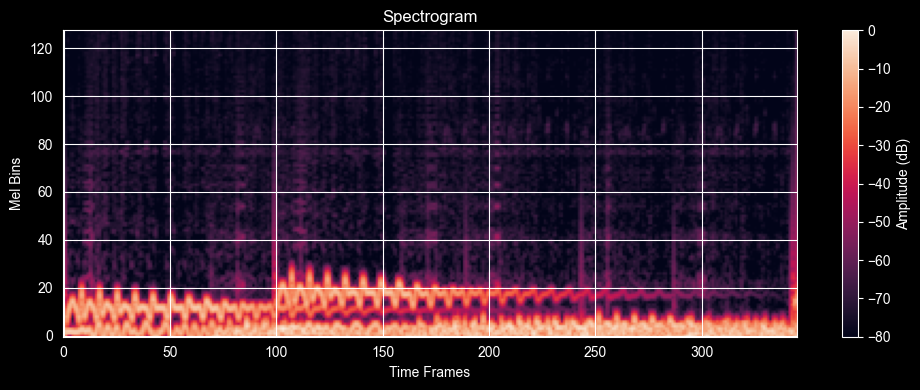

  0%|          | 0/1229911 [00:47<?, ?it/s]


In [11]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

dataloader = torch.utils.data.DataLoader(
        dataset, batch_size=1, shuffle=True, num_workers=4, persistent_workers=True,
    )

for batch in tqdm(dataloader):
    spectrogram, notes, patch, midi_mask = batch
    spectrogram = spectrogram.squeeze(0).detach().numpy()

    plt.figure(figsize=(10, 4))
    plt.imshow(spectrogram, aspect='auto', origin='lower')
    plt.colorbar(label="Amplitude (dB)")
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Bins")
    plt.title("Spectrogram")
    plt.tight_layout()
    plt.show()

    break